In [10]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to C:\Users\DIMPLE
[nltk_data]     MUNDHRA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\DIMPLE
[nltk_data]     MUNDHRA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\DIMPLE
[nltk_data]     MUNDHRA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [13]:
imdb_reviews = pd.read_csv(r'C:\Users\DIMPLE MUNDHRA\OneDrive\文档\DataScienceProject_1\IMDB_datasets.csv')
imdb_reviews.head(10)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [15]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t.lower() not in stop_words]
    tokens = [t for t in tokens if t.isalpha()]
    
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t.lower()) for t in tokens]
    
    return ' '.join(tokens)


In [16]:
imdb_reviews['processed_review'] = imdb_reviews['review'].apply(preprocess_text)
imdb_reviews.head()

,review,sentiment,processed_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


In [17]:
imdb_reviews['sentiment'] = imdb_reviews['sentiment'].map({
    'negative': 0,
    'positive': 1
})

In [18]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(imdb_reviews['processed_review'])
y = imdb_reviews['sentiment']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [21]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8948
Precision: 0.8847712796757383
Recall: 0.909704306410002
F1 Score: 0.8970645792563601


In [22]:
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))

              precision    recall  f1-score   support

    negative       0.91      0.88      0.89      4961
    positive       0.88      0.91      0.90      5039

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000



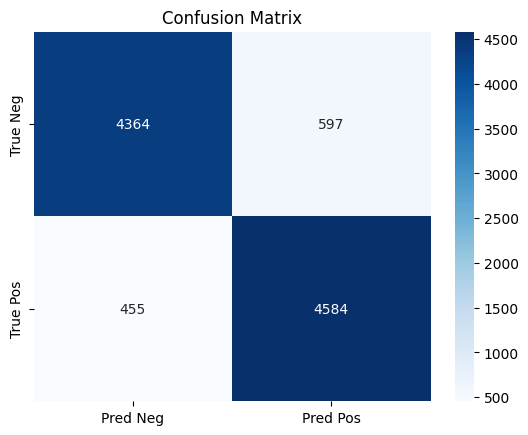

In [23]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Neg", "Pred Pos"],
            yticklabels=["True Neg", "True Pos"])
plt.title("Confusion Matrix")
plt.show()

In [24]:
def predict_sentiment(review):
    processed = preprocess_text(review)
    vector = vectorizer.transform([processed])
    pred = model.predict(vector)[0]
    return "Positive ✅" if pred == 1 else "Negative ❌"

In [27]:
sample = "This movie was absolutely amazing, great acting!"
print("Review:", sample)
print("Sentiment:", predict_sentiment(sample))

Review: This movie was absolutely amazing, great acting!
Sentiment: Positive ✅
